---
# Data Science for Feature Engineering
## Part 1: Can We Predict Stock Returns from Historical Data?

##### *"In God we trust. All others must bring data."* — W. Edwards Deming

### Director Harold · Lecture Series: Data Science for Feature Engineering

---

### What this lecture covers

This is the first lecture in the **Data Science for Feature Engineering** series.

| Stage | What we do | Why it matters |
|---|---|---|
| **A. Dataset tour** | Understand the data used for the whole series | You can't model what you don't understand |
| **B. Market context** | Add SPY, VIX, yield curve as macro features | Individual stocks don't exist in a vacuum |
| **C. Single stock** | Deep dive on AAPL | Build intuition before scaling up |
| **D. Panel data** | Cross-sectional view across 50 stocks | More observations = better statistical power |
| **E. Feature engineering** | Build momentum, volatility, volume, macro features | Our prediction inputs |
| **F. First prediction test** | IC analysis and quintile portfolios | Does any feature actually predict returns? |

---

### The dataset used in this entire series

- **`ds4fe_panel.parquet`** — 50 large-cap US stocks, daily OHLCV, 2010–2024 (187k rows)
- **`ds4fe_market.parquet`** — SPY + macro data (VIX, Treasury yields, USD index)
- **`ds4fe_info.csv`** — ticker metadata (sector, company name, market cap)

In Part 4 we will add limit order book (LOB) data for intraday features.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Load the shared dataset ────────────────────────────────────────
DATA_DIR = 'data'

panel  = pd.read_parquet(f'{DATA_DIR}/ds4fe_panel.parquet')
market = pd.read_parquet(f'{DATA_DIR}/ds4fe_market.parquet')
info   = pd.read_csv(f'{DATA_DIR}/ds4fe_info.csv')

panel['date']  = pd.to_datetime(panel['date'])
market['date'] = pd.to_datetime(market['date'])

ticker_sector = info.set_index('ticker')['sector'].to_dict()
ticker_name   = info.set_index('ticker')['short_name'].to_dict()

sectors  = sorted(info['sector'].dropna().unique())
palette  = dict(zip(sectors, plt.cm.tab10.colors[:len(sectors)]))

print(f'panel  : {panel.shape[0]:>8,} rows  |  cols: {list(panel.columns)}')
print(f'market : {market.shape[0]:>8,} rows  |  cols: {list(market.columns)}')
print(f'info   : {len(info)} tickers  |  date range: {panel["date"].min().date()} to {panel["date"].max().date()}')

panel  :  187,247 rows  |  cols: ['date', 'ticker', 'close', 'volume', 'high', 'low', 'open', 'ret', 'sector', 'ret_fwd']
market :    3,771 rows  |  cols: ['date', 'spy_close', 'vix', 'yield_10y', 'yield_3m', 'usd_index', 'spy_volume', 'market_ret', 'yield_spread']
info   : 50 tickers  |  date range: 2010-01-05 to 2024-12-30


---
# Part A: Dataset Tour

Before modeling anything, explore the data first. This section answers: what do we have, how complete is it, what does it look like?

---

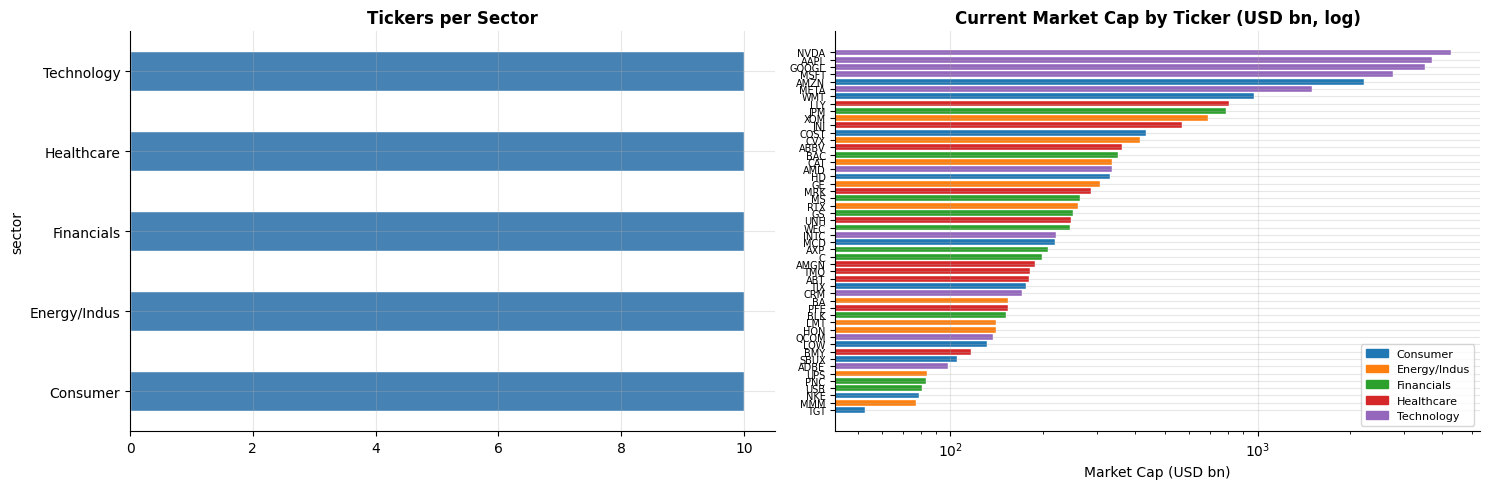

In [2]:
# ── A1. Ticker overview ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sector count
sector_counts = info.groupby('sector')['ticker'].count().sort_values()
sector_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Tickers per Sector', fontweight='bold')

# Market cap (log scale)
info_c = info.dropna(subset=['market_cap']).sort_values('market_cap')
bar_colors = [palette.get(s, 'gray') for s in info_c['sector']]
axes[1].barh(info_c['ticker'], info_c['market_cap'] / 1e9, color=bar_colors, edgecolor='white', linewidth=0.3)
axes[1].set_xscale('log')
axes[1].set_title('Current Market Cap by Ticker (USD bn, log)', fontweight='bold')
axes[1].set_xlabel('Market Cap (USD bn)')
axes[1].tick_params(axis='y', labelsize=7)
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in palette.items()]
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

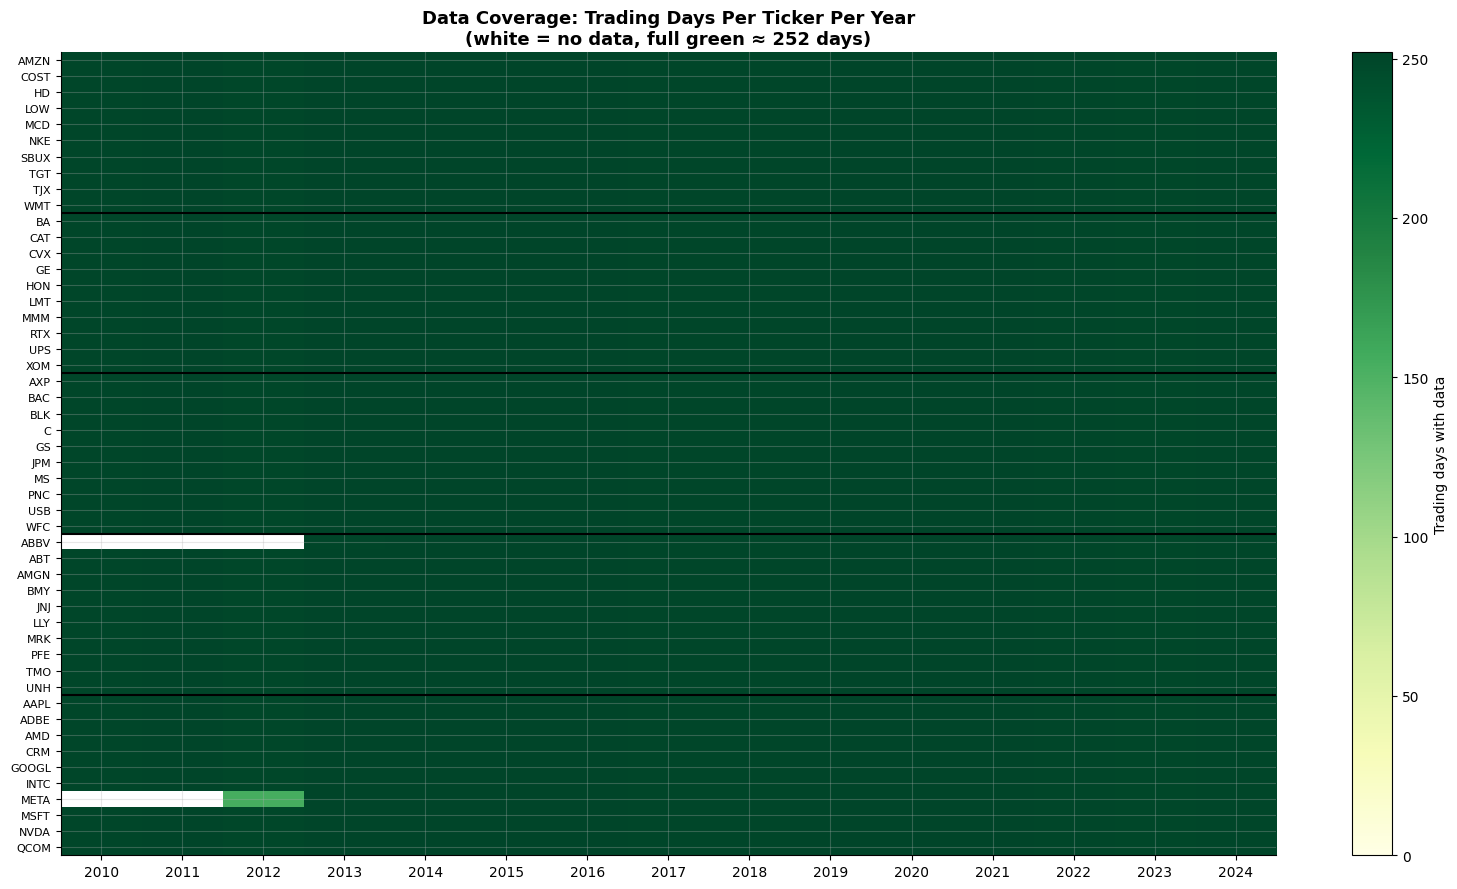

Some tickers have missing early years — they were listed after 2010:
  META IPO: 2012  |  ABBV spin-off: 2013


In [3]:
# ── A2. Data coverage heatmap ─────────────────────────────────────
panel['year'] = panel['date'].dt.year
coverage = panel.groupby(['ticker', 'year'])['ret'].count().unstack('year')

ticker_order = info.sort_values(['sector', 'ticker'])['ticker'].tolist()
ticker_order = [t for t in ticker_order if t in coverage.index]
coverage = coverage.loc[ticker_order]

fig, ax = plt.subplots(figsize=(16, 9))
im = ax.imshow(coverage.values, cmap='YlGn', aspect='auto', vmin=0, vmax=252)
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns)
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Trading days with data')

current = None
for i, t in enumerate(coverage.index):
    s = ticker_sector.get(t)
    if s != current and current is not None:
        ax.axhline(i - 0.5, color='black', linewidth=1.5)
    current = s

ax.set_title('Data Coverage: Trading Days Per Ticker Per Year\n(white = no data, full green ≈ 252 days)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Some tickers have missing early years — they were listed after 2010:')
print('  META IPO: 2012  |  ABBV spin-off: 2013')

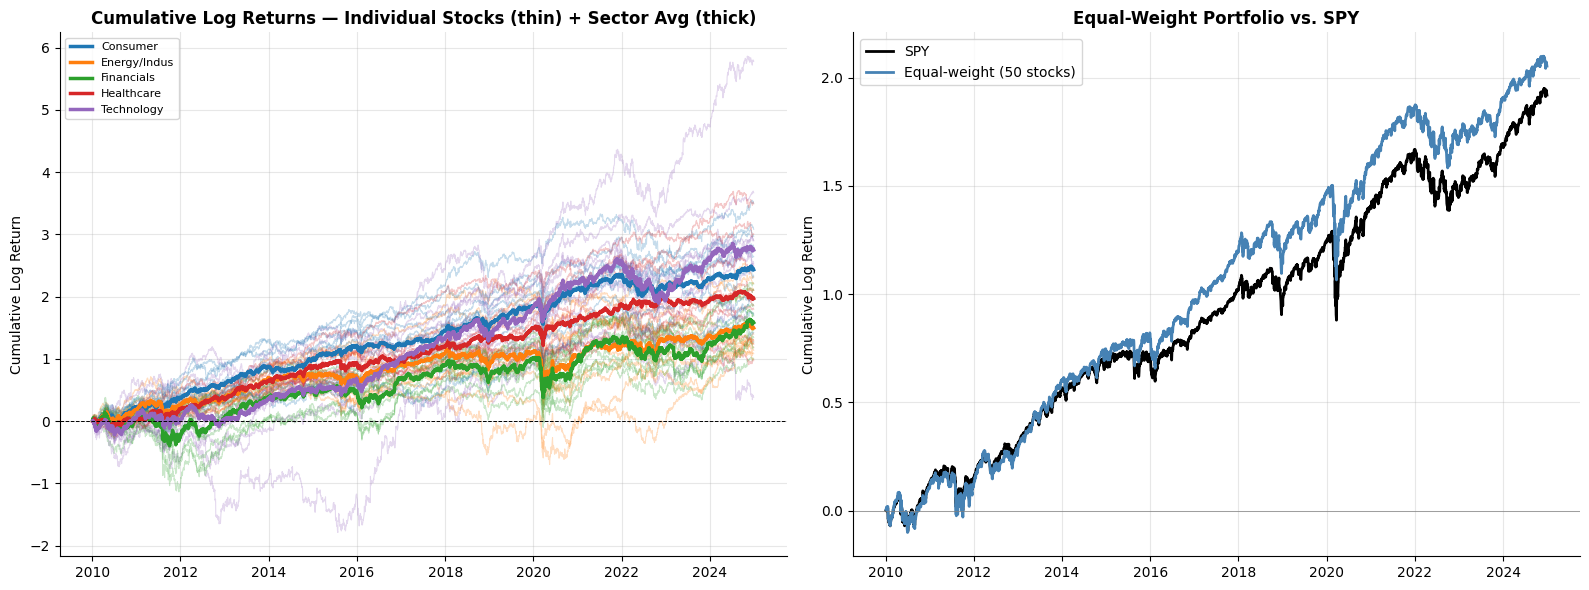

In [4]:
# ── A3. Cumulative returns by sector ─────────────────────────────
panel_s = panel.sort_values(['ticker', 'date'])
panel_s['cum_ret'] = panel_s.groupby('ticker')['ret'].cumsum()

sector_cum = panel_s.groupby(['sector', 'date'])['cum_ret'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ticker, grp in panel_s.groupby('ticker'):
    s = ticker_sector.get(ticker, 'Other')
    axes[0].plot(grp['date'], grp['cum_ret'], color=palette.get(s, 'gray'), alpha=0.25, linewidth=0.8)
for s, grp in sector_cum.groupby('sector'):
    axes[0].plot(grp['date'], grp['cum_ret'], color=palette.get(s, 'gray'), linewidth=2.5, label=s)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_title('Cumulative Log Returns — Individual Stocks (thin) + Sector Avg (thick)', fontweight='bold')
axes[0].set_ylabel('Cumulative Log Return')
axes[0].legend(fontsize=8, loc='upper left')

spy_cum = np.log(market['spy_close'] / market['spy_close'].iloc[0])
eq_weight = panel_s.groupby('date')['ret'].mean().cumsum()
axes[1].plot(market['date'], spy_cum, 'k-', linewidth=2, label='SPY')
axes[1].plot(eq_weight.index, eq_weight.values, color='steelblue', linewidth=2, label='Equal-weight (50 stocks)')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_title('Equal-Weight Portfolio vs. SPY', fontweight='bold')
axes[1].set_ylabel('Cumulative Log Return')
axes[1].legend()

plt.tight_layout()
plt.show()

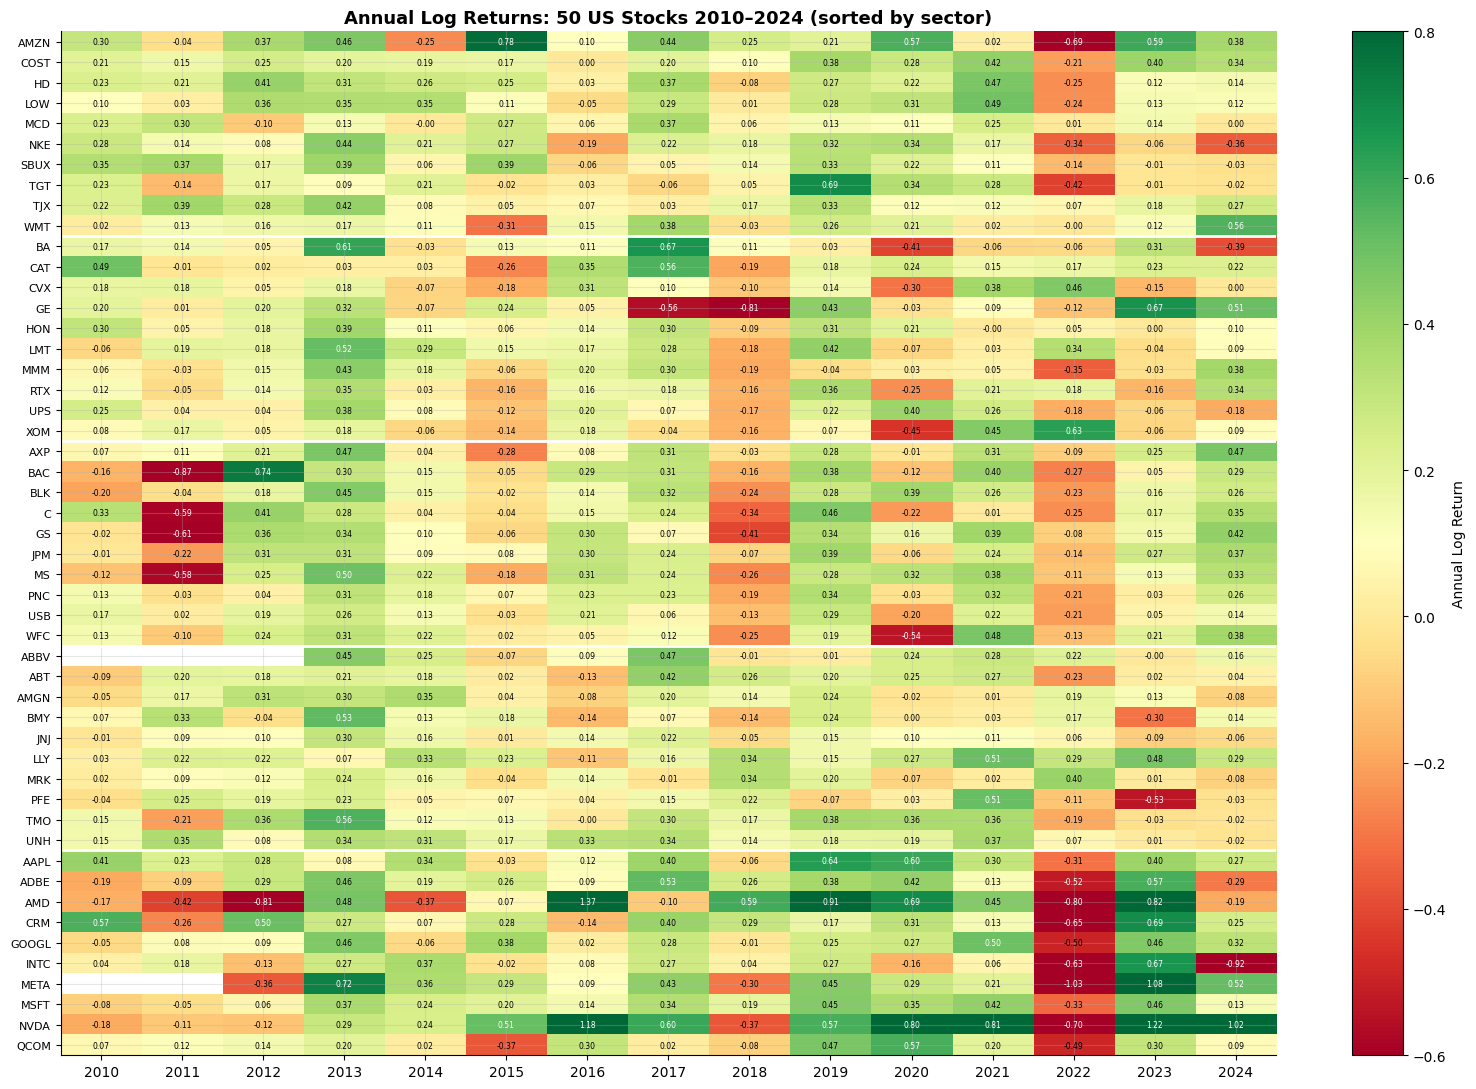

In [5]:
# ── A4. Annual return heatmap ─────────────────────────────────────
annual_ret = panel.groupby(['ticker', 'year'])['ret'].sum().unstack('year')
annual_ret = annual_ret.loc[[t for t in ticker_order if t in annual_ret.index]]

fig, ax = plt.subplots(figsize=(16, 11))
im = ax.imshow(annual_ret.values, cmap='RdYlGn', aspect='auto', vmin=-0.6, vmax=0.8)
ax.set_xticks(range(len(annual_ret.columns)))
ax.set_xticklabels(annual_ret.columns)
ax.set_yticks(range(len(annual_ret.index)))
ax.set_yticklabels(annual_ret.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Annual Log Return')

for i in range(len(annual_ret.index)):
    for j in range(len(annual_ret.columns)):
        v = annual_ret.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5.5,
                    color='black' if abs(v) < 0.5 else 'white')

current = None
for i, t in enumerate(annual_ret.index):
    s = ticker_sector.get(t)
    if s != current and current is not None:
        ax.axhline(i - 0.5, color='white', linewidth=2)
    current = s

ax.set_title('Annual Log Returns: 50 US Stocks 2010–2024 (sorted by sector)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

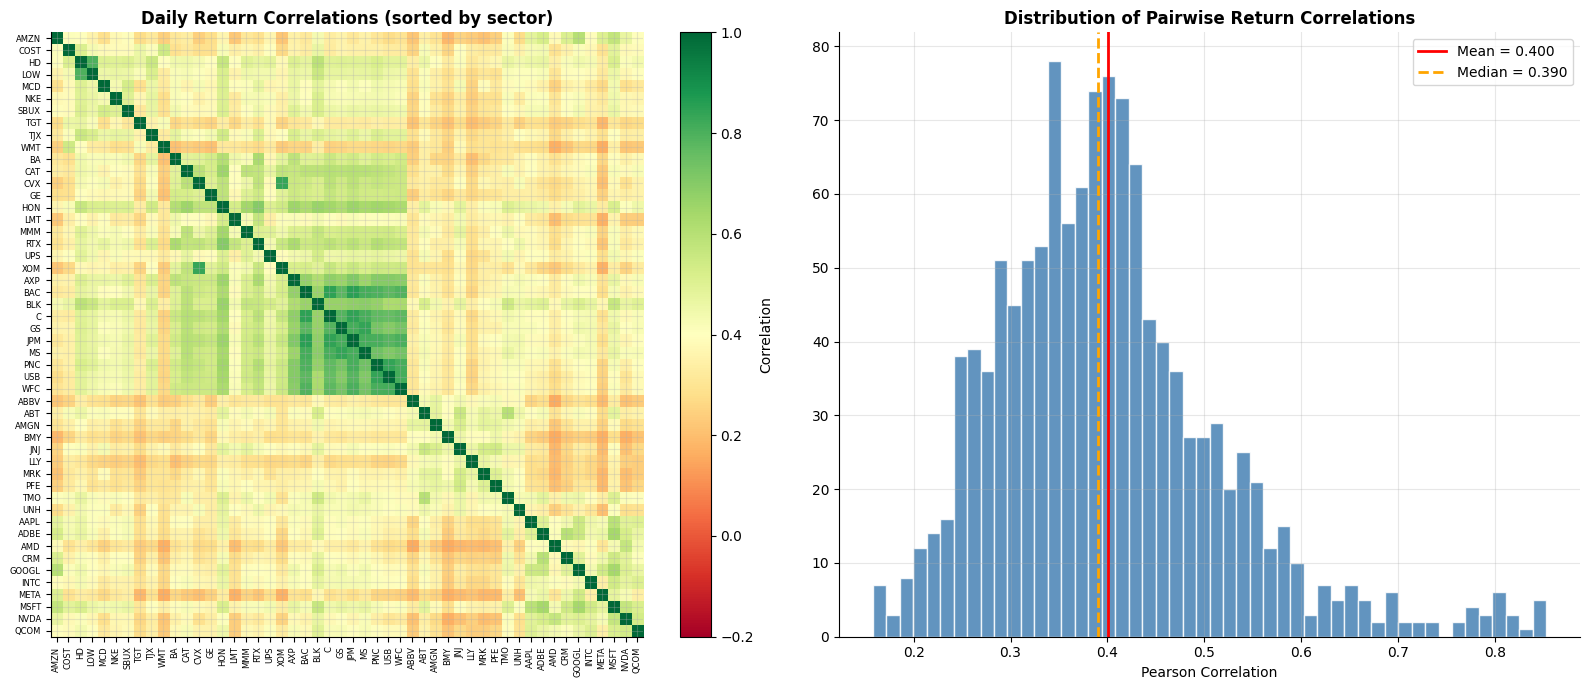

Average pairwise correlation: 0.400
Market explains ~40% of daily co-movement.
The remaining ~60% is stock-specific — where alpha lives.


In [6]:
# ── A5. Return correlation heatmap ────────────────────────────────
ret_wide = panel.pivot(index='date', columns='ticker', values='ret').dropna(how='all')
sorted_t = [t for t in ticker_order if t in ret_wide.columns]
corr = ret_wide[sorted_t].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im = axes[0].imshow(corr.values, cmap='RdYlGn', vmin=-0.2, vmax=1.0, aspect='auto')
axes[0].set_xticks(range(len(sorted_t)))
axes[0].set_yticks(range(len(sorted_t)))
axes[0].set_xticklabels(sorted_t, rotation=90, fontsize=6)
axes[0].set_yticklabels(sorted_t, fontsize=6)
plt.colorbar(im, ax=axes[0], label='Correlation')
axes[0].set_title('Daily Return Correlations (sorted by sector)', fontweight='bold')

upper = corr.values[np.triu_indices_from(corr.values, k=1)]
axes[1].hist(upper, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(upper.mean(), color='red', linewidth=2, label=f'Mean = {upper.mean():.3f}')
axes[1].axvline(np.median(upper), color='orange', linewidth=2, linestyle='--', label=f'Median = {np.median(upper):.3f}')
axes[1].set_title('Distribution of Pairwise Return Correlations', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Average pairwise correlation: {upper.mean():.3f}')
print(f'Market explains ~{upper.mean()*100:.0f}% of daily co-movement.')
print(f'The remaining ~{(1-upper.mean())*100:.0f}% is stock-specific — where alpha lives.')

---
# Part B: Market Context — SPY, VIX, and the Yield Curve

Individual stock returns do not happen in isolation. Market-wide forces drive large portions of every stock's daily return.

| Variable | What it measures | Why it matters |
|---|---|---|
| **SPY return** | Daily S&P 500 return | Beta — most stocks move with the market |
| **VIX** | Implied volatility (fear index) | High VIX = risk-off, stocks tend to fall |
| **Yield spread (10y−3m)** | Term premium / yield curve slope | Inverted = recession signal |
| **USD index** | Strength of the dollar | Strong USD can hurt multinationals |

---

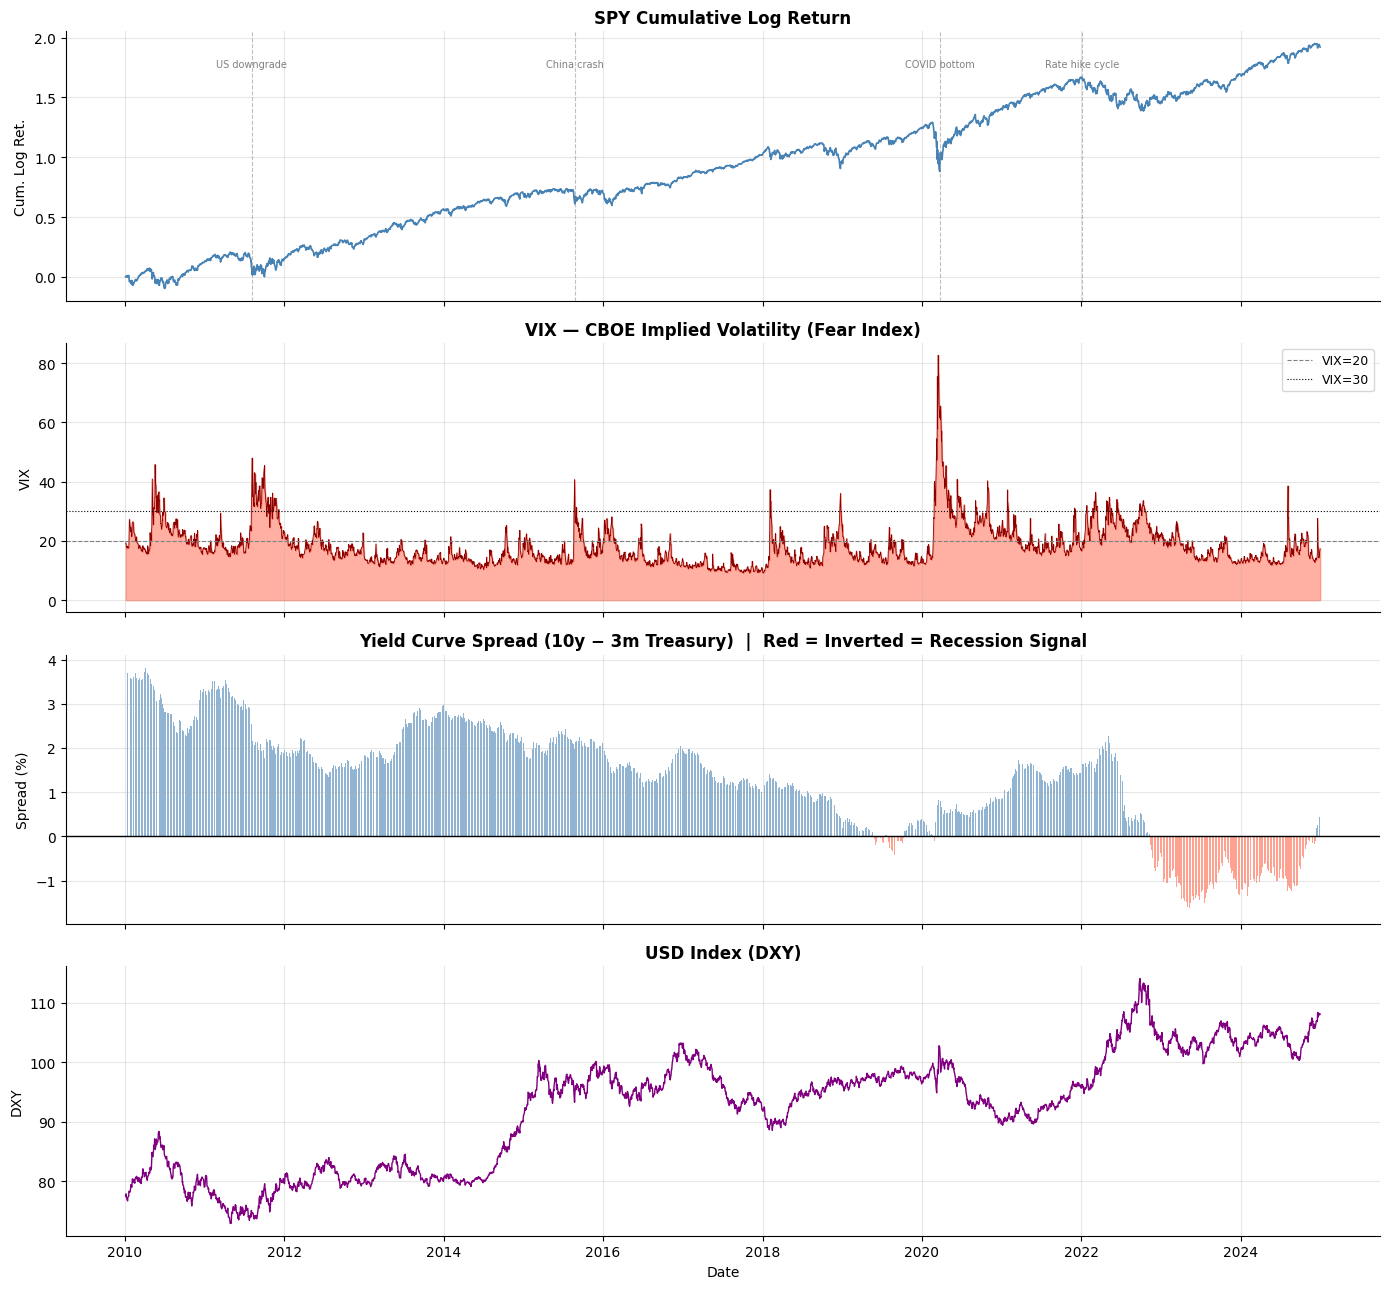

In [7]:
# ── B1. Macro time series overview ───────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

spy_cum = np.log(market['spy_close'] / market['spy_close'].iloc[0])
axes[0].plot(market['date'], spy_cum, color='steelblue', linewidth=1.2)
axes[0].set_title('SPY Cumulative Log Return', fontweight='bold')
axes[0].set_ylabel('Cum. Log Ret.')

axes[1].fill_between(market['date'], market['vix'], alpha=0.5, color='tomato')
axes[1].plot(market['date'], market['vix'], color='darkred', linewidth=0.6)
axes[1].axhline(20, color='gray', linewidth=0.8, linestyle='--', label='VIX=20')
axes[1].axhline(30, color='black', linewidth=0.8, linestyle=':', label='VIX=30')
axes[1].set_title('VIX — CBOE Implied Volatility (Fear Index)', fontweight='bold')
axes[1].set_ylabel('VIX')
axes[1].legend(fontsize=9)

spread = market['yield_spread']
bar_colors = np.where(spread < 0, 'tomato', 'steelblue')
axes[2].bar(market['date'], spread, color=bar_colors, alpha=0.6, width=1)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Yield Curve Spread (10y − 3m Treasury)  |  Red = Inverted = Recession Signal', fontweight='bold')
axes[2].set_ylabel('Spread (%)')

axes[3].plot(market['date'], market['usd_index'], color='purple', linewidth=1)
axes[3].set_title('USD Index (DXY)', fontweight='bold')
axes[3].set_ylabel('DXY')
axes[3].set_xlabel('Date')

events = {'2011-08-05': 'US downgrade', '2015-08-24': 'China crash',
          '2020-03-23': 'COVID bottom', '2022-01-03': 'Rate hike cycle'}
for d_str, lbl in events.items():
    d = pd.Timestamp(d_str)
    axes[0].axvline(d, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[0].text(d, spy_cum.max() * 0.90, lbl, fontsize=7, ha='center', color='gray')

plt.tight_layout()
plt.show()

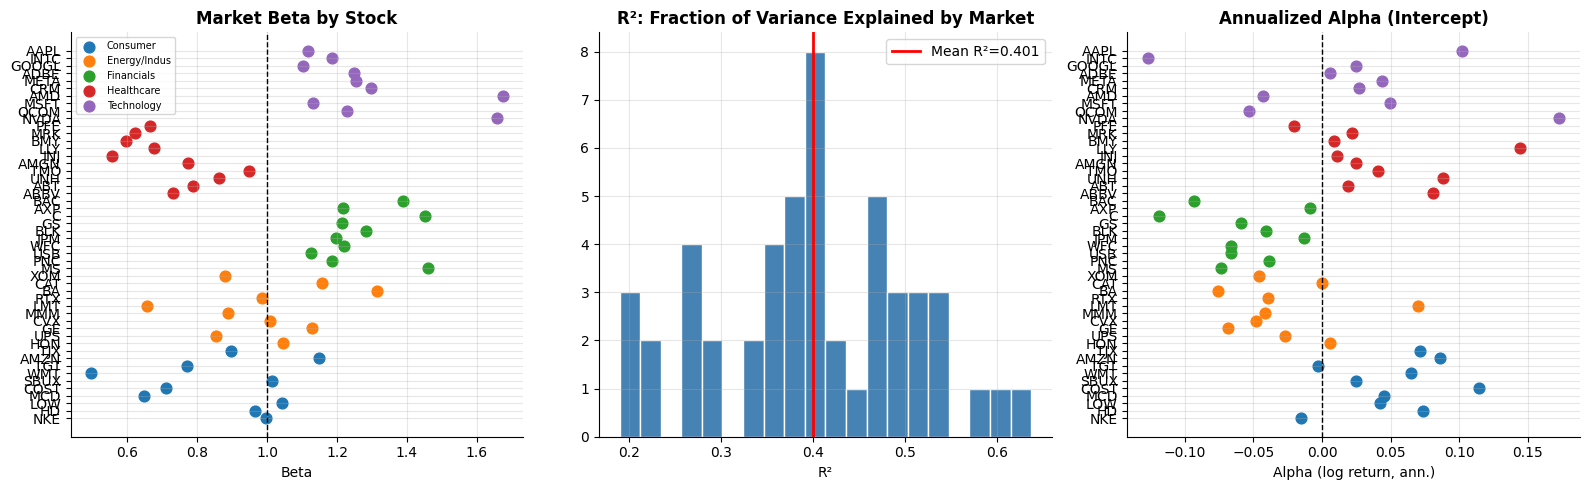

Average R² = 0.40 — the market explains ~40% of daily variance.
The remaining ~60% is idiosyncratic — where stock-specific features matter.


In [8]:
# ── B2. Market beta and R² per stock ─────────────────────────────
panel_m = panel.merge(
    market[['date', 'market_ret', 'vix', 'yield_spread', 'usd_index', 'spy_volume']],
    on='date', how='left'
)

beta_rows = []
for ticker, grp in panel_m.groupby('ticker'):
    valid = grp[['ret', 'market_ret']].dropna()
    if len(valid) < 100:
        continue
    slope, intercept, r_val, pval, _ = stats.linregress(valid['market_ret'], valid['ret'])
    beta_rows.append({'ticker': ticker, 'sector': ticker_sector.get(ticker),
                      'beta': slope, 'alpha_ann': intercept * 252, 'r2': r_val**2})

betas = pd.DataFrame(beta_rows).sort_values('sector')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for s, grp in betas.groupby('sector'):
    axes[0].scatter(grp['beta'], grp['ticker'], color=palette.get(s), s=60, label=s)
axes[0].axvline(1.0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Market Beta by Stock', fontweight='bold')
axes[0].set_xlabel('Beta')
axes[0].legend(fontsize=7)

axes[1].hist(betas['r2'], bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(betas['r2'].mean(), color='red', linewidth=2, label=f'Mean R²={betas["r2"].mean():.3f}')
axes[1].set_title('R²: Fraction of Variance Explained by Market', fontweight='bold')
axes[1].set_xlabel('R²')
axes[1].legend()

for s, grp in betas.groupby('sector'):
    axes[2].scatter(grp['alpha_ann'], grp['ticker'], color=palette.get(s), s=60)
axes[2].axvline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Annualized Alpha (Intercept)', fontweight='bold')
axes[2].set_xlabel('Alpha (log return, ann.)')

plt.tight_layout()
plt.show()

print(f'Average R² = {betas["r2"].mean():.2f} — the market explains ~{betas["r2"].mean()*100:.0f}% of daily variance.')
print(f'The remaining ~{(1-betas["r2"].mean())*100:.0f}% is idiosyncratic — where stock-specific features matter.')

---
# Part C: Single Stock Deep Dive — AAPL
---

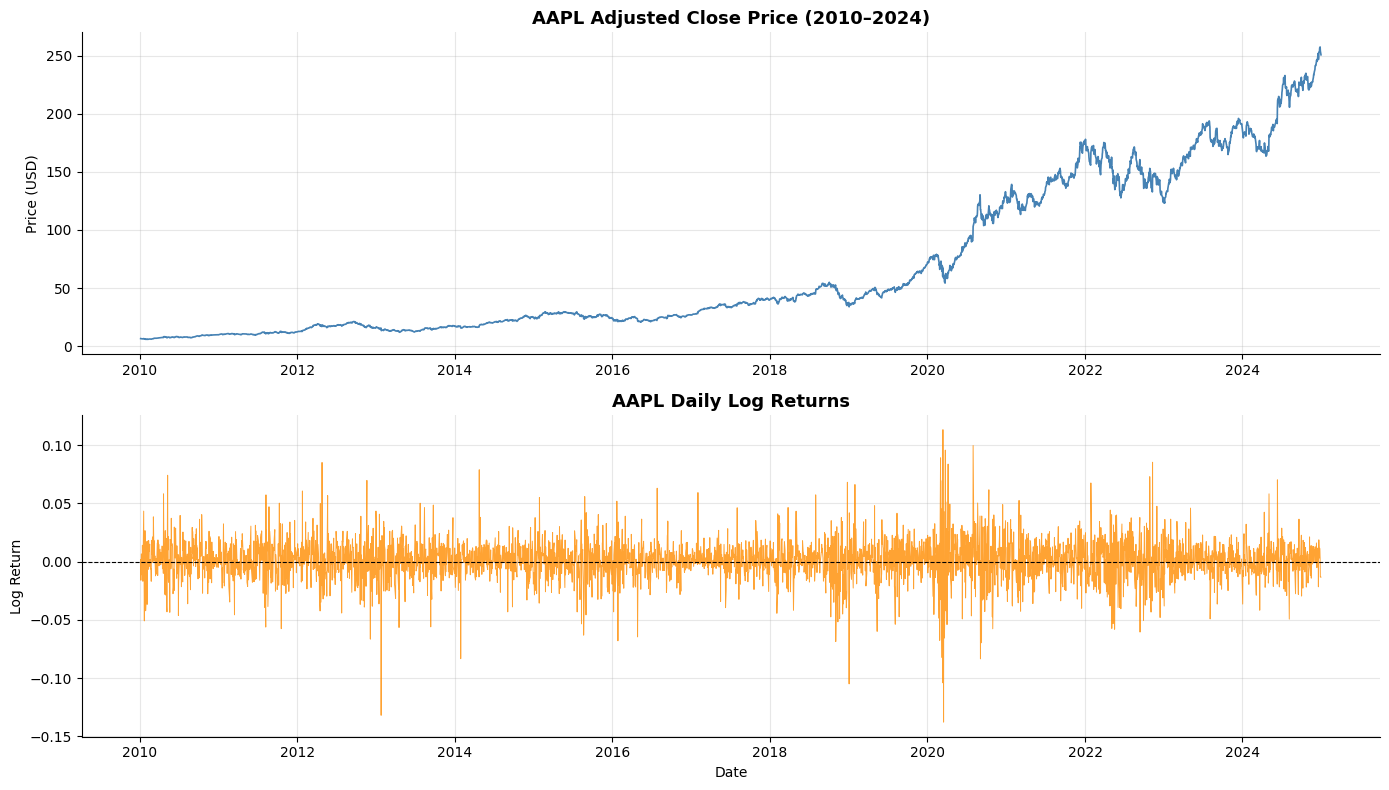

=== AAPL Daily Return Statistics ===
Mean (ann.)  : 24.50%   |   Vol (ann.) : 27.88%
Sharpe       : 0.88   |   Kurtosis   : 5.45  (normal=0)   |   Skew: -0.2353


In [9]:
# ── C1. Price vs. return ──────────────────────────────────────────
aapl = panel[panel['ticker'] == 'AAPL'].sort_values('date').copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(aapl['date'], aapl['close'], color='steelblue', linewidth=1.2)
axes[0].set_title('AAPL Adjusted Close Price (2010–2024)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(aapl['date'], aapl['ret'], color='darkorange', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('AAPL Daily Log Returns', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log Return')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

r = aapl['ret']
print('=== AAPL Daily Return Statistics ===')
print(f'Mean (ann.)  : {r.mean()*252:.2%}   |   Vol (ann.) : {r.std()*np.sqrt(252):.2%}')
print(f'Sharpe       : {r.mean()/r.std()*np.sqrt(252):.2f}   |   Kurtosis   : {r.kurtosis():.2f}  (normal=0)   |   Skew: {r.skew():.4f}')

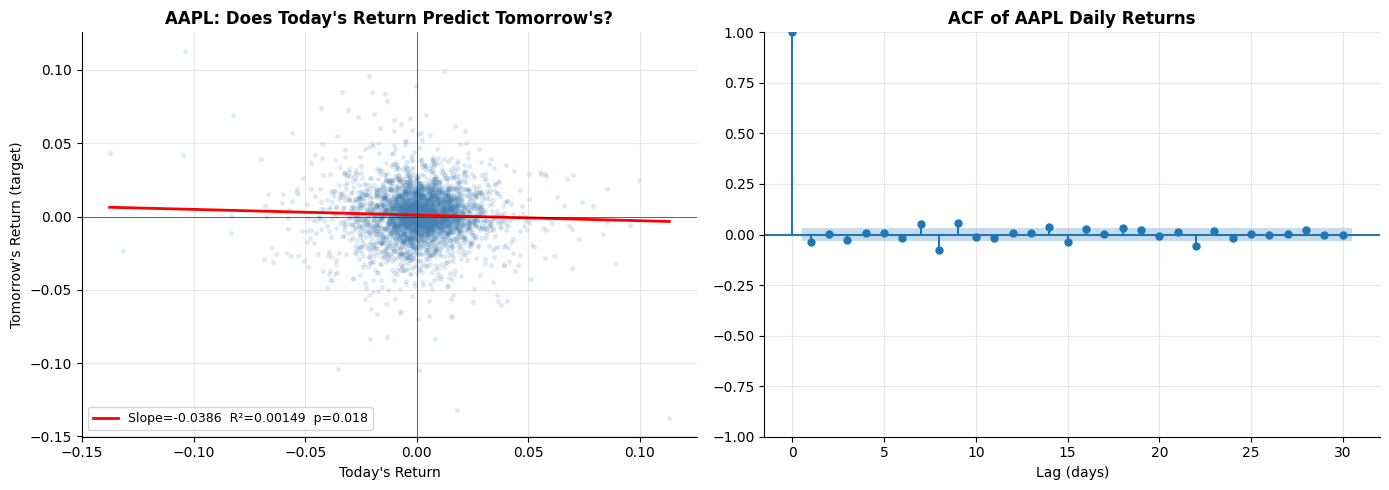

R² = 0.001492 — raw lagged return explains essentially nothing.
This motivates building richer features. A single lag is not enough.


In [10]:
# ── C2. Does yesterday predict tomorrow? ─────────────────────────
aapl_lag = pd.DataFrame({'x': aapl['ret'].values, 'y': aapl['ret_fwd'].values}).dropna()
slope, intercept, r_val, pval, _ = stats.linregress(aapl_lag['x'], aapl_lag['y'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(aapl_lag['x'], aapl_lag['y'], alpha=0.12, s=7, color='steelblue')
xl = np.linspace(aapl_lag['x'].min(), aapl_lag['x'].max(), 100)
axes[0].plot(xl, intercept + slope * xl, 'r-', linewidth=2,
             label=f'Slope={slope:.4f}  R²={r_val**2:.5f}  p={pval:.3f}')
axes[0].axhline(0, color='black', linewidth=0.4)
axes[0].axvline(0, color='black', linewidth=0.4)
axes[0].set_xlabel("Today's Return")
axes[0].set_ylabel("Tomorrow's Return (target)")
axes[0].set_title('AAPL: Does Today\'s Return Predict Tomorrow\'s?', fontweight='bold')
axes[0].legend(fontsize=9)

plot_acf(aapl['ret'].dropna(), lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of AAPL Daily Returns', fontweight='bold')
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()
print(f'R² = {r_val**2:.6f} — raw lagged return explains essentially nothing.')
print('This motivates building richer features. A single lag is not enough.')

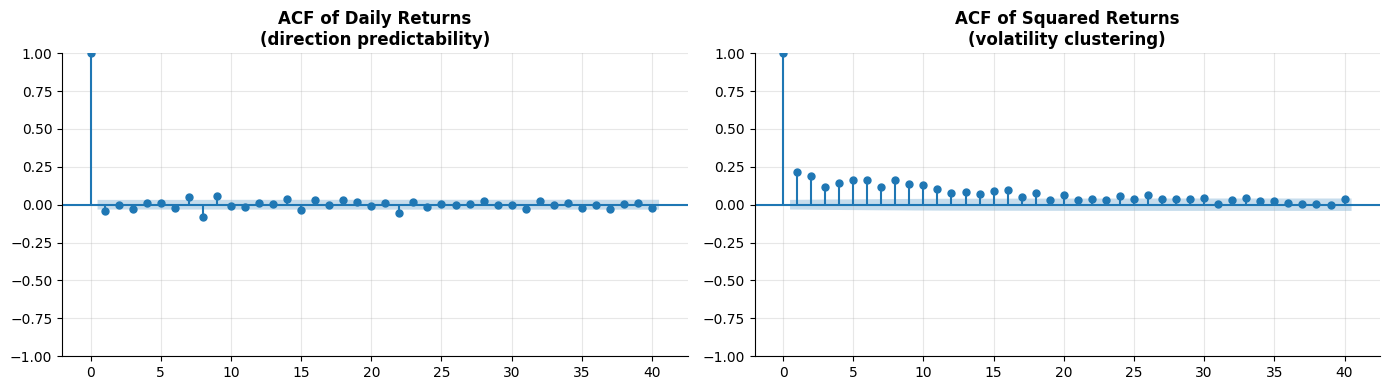

Returns:         autocorrelations mostly insignificant → direction is hard to predict
Squared returns: strong, persistent autocorrelation → volatility IS predictable
Implication: realized volatility is a useful feature — both as signal and risk measure.


In [11]:
# ── C3. Volatility clustering ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(aapl['ret'].dropna(),    lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Daily Returns\n(direction predictability)', fontweight='bold')
plot_acf(aapl['ret'].dropna()**2, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of Squared Returns\n(volatility clustering)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Returns:         autocorrelations mostly insignificant → direction is hard to predict')
print('Squared returns: strong, persistent autocorrelation → volatility IS predictable')
print('Implication: realized volatility is a useful feature — both as signal and risk measure.')

---
# Part D: Panel Data — 50 Stocks

Single stock = ~3,500 observations. Panel (50 stocks) = ~175,000 observations.

More importantly, panel data lets us ask a **different question**:
> "Which stocks will *outperform the others* tomorrow?" — the **cross-sectional prediction** problem.

---

---
# Part E: Feature Engineering

We build four families of features:

| Family | Features | Intuition |
|---|---|---|
| **Momentum** | 1d, 5d, 21d, 63d past returns | Past winners keep winning (medium-term) |
| **Volatility** | 21d, 63d realized vol | High-vol stocks behave differently |
| **Volume/Liquidity** | Volume ratio, Amihud ILLIQ | Unusual activity carries signal |
| **Macro** | SPY return, VIX, yield spread, USD | Market-wide conditions affect all stocks |

**Golden rule**: every feature at date $t$ uses only data available at close of day $t$. Target = $r_{t+1}$.

---

In [12]:
def build_features(panel_df, market_df):
    ret_w   = panel_df.pivot(index='date', columns='ticker', values='ret')
    vol_w   = panel_df.pivot(index='date', columns='ticker', values='volume')
    close_w = panel_df.pivot(index='date', columns='ticker', values='close')

    feats = {}
    # Momentum — shift(1): most recent known return is yesterday's
    feats['mom_1d']  = ret_w.shift(1)
    feats['mom_5d']  = ret_w.shift(1).rolling(5).sum()
    feats['mom_21d'] = ret_w.shift(1).rolling(21).sum()
    feats['mom_63d'] = ret_w.shift(1).rolling(63).sum()
    # Volatility
    feats['vol_21d'] = ret_w.shift(1).rolling(21).std() * np.sqrt(252)
    feats['vol_63d'] = ret_w.shift(1).rolling(63).std() * np.sqrt(252)
    # Volume / Liquidity
    feats['volume_ratio'] = vol_w.shift(1) / (vol_w.shift(1).rolling(20).mean() + 1e-10)
    dollar_vol = vol_w * close_w
    feats['illiq_21d'] = (ret_w.abs() / (dollar_vol + 1e-10)).shift(1).rolling(21).mean() * 1e6
    # Target
    feats['ret_fwd'] = ret_w

    long_dfs = []
    for name, w in feats.items():
        s = w.stack().rename(name)
        s.index.names = ['date', 'ticker']
        long_dfs.append(s)
    result = pd.concat(long_dfs, axis=1).reset_index()

    # Merge macro features (lag by 1 day)
    macro_cols = ['date', 'market_ret', 'vix', 'yield_spread', 'usd_index', 'spy_volume']
    result = result.merge(market_df[macro_cols], on='date', how='left')
    for col in ['market_ret', 'vix', 'yield_spread', 'usd_index', 'spy_volume']:
        result[col] = result.groupby('ticker')[col].shift(1)

    result['sector'] = result['ticker'].map(ticker_sector)
    result = result.dropna(subset=['mom_1d', 'ret_fwd']).reset_index(drop=True)
    return result


print('Building features...')
feat = build_features(panel_m, market)

FEATURE_COLS = ['mom_1d', 'mom_5d', 'mom_21d', 'mom_63d',
                'vol_21d', 'vol_63d', 'volume_ratio', 'illiq_21d',
                'market_ret', 'vix', 'yield_spread', 'usd_index']

print(f'Feature panel: {feat.shape[0]:,} rows')
feat[['date', 'ticker', 'sector'] + FEATURE_COLS[:4] + ['ret_fwd']].head()

Building features...


Feature panel: 187,197 rows


,date,ticker,sector,mom_1d,mom_5d,mom_21d,mom_63d,ret_fwd
0,2010-01-06,AAPL,Technology,0.001728,NaN,NaN,NaN,-0.016034
1,2010-01-06,ABT,Healthcare,-0.008112,NaN,NaN,NaN,0.005538
2,2010-01-06,ADBE,Technology,0.016313,NaN,NaN,NaN,-0.002124
3,2010-01-06,AMD,Technology,0.001030,NaN,NaN,NaN,-0.014523
4,2010-01-06,AMGN,Healthcare,-0.008700,NaN,NaN,NaN,-0.007544


In [13]:
feat[FEATURE_COLS + ['ret_fwd']].describe().round(5)

,mom_1d,mom_5d,mom_21d,mom_63d,vol_21d,vol_63d,volume_ratio,illiq_21d,market_ret,vix,yield_spread,usd_index,ret_fwd
count,187197.00000,186997.00000,186197.00000,184097.00000,186197.00000,184097.00000,186247.00000,186197.00000,187097.00000,187097.00000,187097.00000,187097.00000,187197.00000
mean,0.00055,0.00274,0.01174,0.03549,0.25011,0.25862,1.00673,0.00003,0.00051,18.34821,1.28989,92.28912,0.00055
std,0.01810,0.03930,0.07866,0.13128,0.14305,0.12626,0.43077,0.00005,0.01077,6.96165,1.22906,9.34551,0.01810
min,-0.30639,-0.62105,-1.26396,-1.24124,0.03692,0.06306,0.00000,0.00000,-0.11589,9.14000,-1.70400,72.93000,-0.30639
25%,-0.00744,-0.01599,-0.02848,-0.03508,0.16050,0.17826,0.75517,0.00001,-0.00371,13.58000,0.50900,82.27000,-0.00745
50%,0.00064,0.00380,0.01516,0.04123,0.21489,0.22850,0.91795,0.00002,0.00068,16.54000,1.50100,94.55000,0.00063
75%,0.00887,0.02292,0.05511,0.11118,0.29556,0.29886,1.13939,0.00003,0.00577,21.14000,2.11600,98.79000,0.00887
max,0.42062,0.61400,0.58505,0.76926,2.22261,1.46282,11.33123,0.00187,0.08673,82.69000,3.83400,114.11000,0.42062


In [14]:
# Cross-sectional ranking
for col in FEATURE_COLS:
    feat[col + '_rank'] = feat.groupby('date')[col].rank(pct=True, na_option='keep')

RANK_COLS = [c + '_rank' for c in FEATURE_COLS]
print('Cross-sectional percentile ranks added.')
feat[['date', 'ticker'] + RANK_COLS[:4]].head()

Cross-sectional percentile ranks added.


,date,ticker,mom_1d_rank,mom_5d_rank,mom_21d_rank,mom_63d_rank
0,2010-01-06,AAPL,0.437500,NaN,NaN,NaN
1,2010-01-06,ABT,0.187500,NaN,NaN,NaN
2,2010-01-06,ADBE,0.770833,NaN,NaN,NaN
3,2010-01-06,AMD,0.395833,NaN,NaN,NaN
4,2010-01-06,AMGN,0.166667,NaN,NaN,NaN


---
# Part F: Does Any Feature Predict Returns?

Two standard tests:
1. **IC (Information Coefficient)** — Spearman rank correlation between feature and next-day return, computed each day
2. **Quintile analysis** — sort stocks by feature each day, look at average return per quintile group

---

In [15]:
print('Computing daily IC (may take ~30s)...')

ic_records = []
for date, group in feat.groupby('date'):
    if len(group) < 10:
        continue
    row = {'date': date}
    for col in FEATURE_COLS:
        valid = group[[col, 'ret_fwd']].dropna()
        if len(valid) >= 10:
            c, _ = stats.spearmanr(valid[col], valid['ret_fwd'])
            row[col] = c
        else:
            row[col] = np.nan
    ic_records.append(row)

ic_df = pd.DataFrame(ic_records).set_index('date')

ic_summary = pd.DataFrame({
    'Mean IC': ic_df.mean(),
    'Std IC' : ic_df.std(),
    'IC IR'  : ic_df.mean() / ic_df.std(),
    '% IC>0' : (ic_df > 0).mean() * 100,
    't-stat' : ic_df.mean() / (ic_df.std() / np.sqrt(len(ic_df))),
}).round(4).sort_values('IC IR', key=abs, ascending=False)

print('\n=== IC Summary (sorted by |IC IR|) ===')
ic_summary

Computing daily IC (may take ~30s)...



=== IC Summary (sorted by |IC IR|) ===


,Mean IC,Std IC,IC IR,% IC>0,t-stat
mom_1d,-0.0122,0.2419,-0.0506,47.8653,-3.1048
volume_ratio,0.0065,0.1755,0.0368,51.1801,2.2590
mom_5d,-0.0088,0.2479,-0.0357,48.8465,-2.1893
mom_63d,0.0052,0.2642,0.0197,50.8088,1.2102
vol_21d,-0.0038,0.2777,-0.0138,49.2442,-0.8496
vol_63d,-0.0030,0.2939,-0.0101,49.7216,-0.6218
illiq_21d,0.0014,0.2064,0.0069,50.6497,0.4217
mom_21d,-0.0009,0.2509,-0.0037,50.7558,-0.2263
market_ret,NaN,NaN,NaN,0.0000,NaN
vix,NaN,NaN,NaN,0.0000,NaN


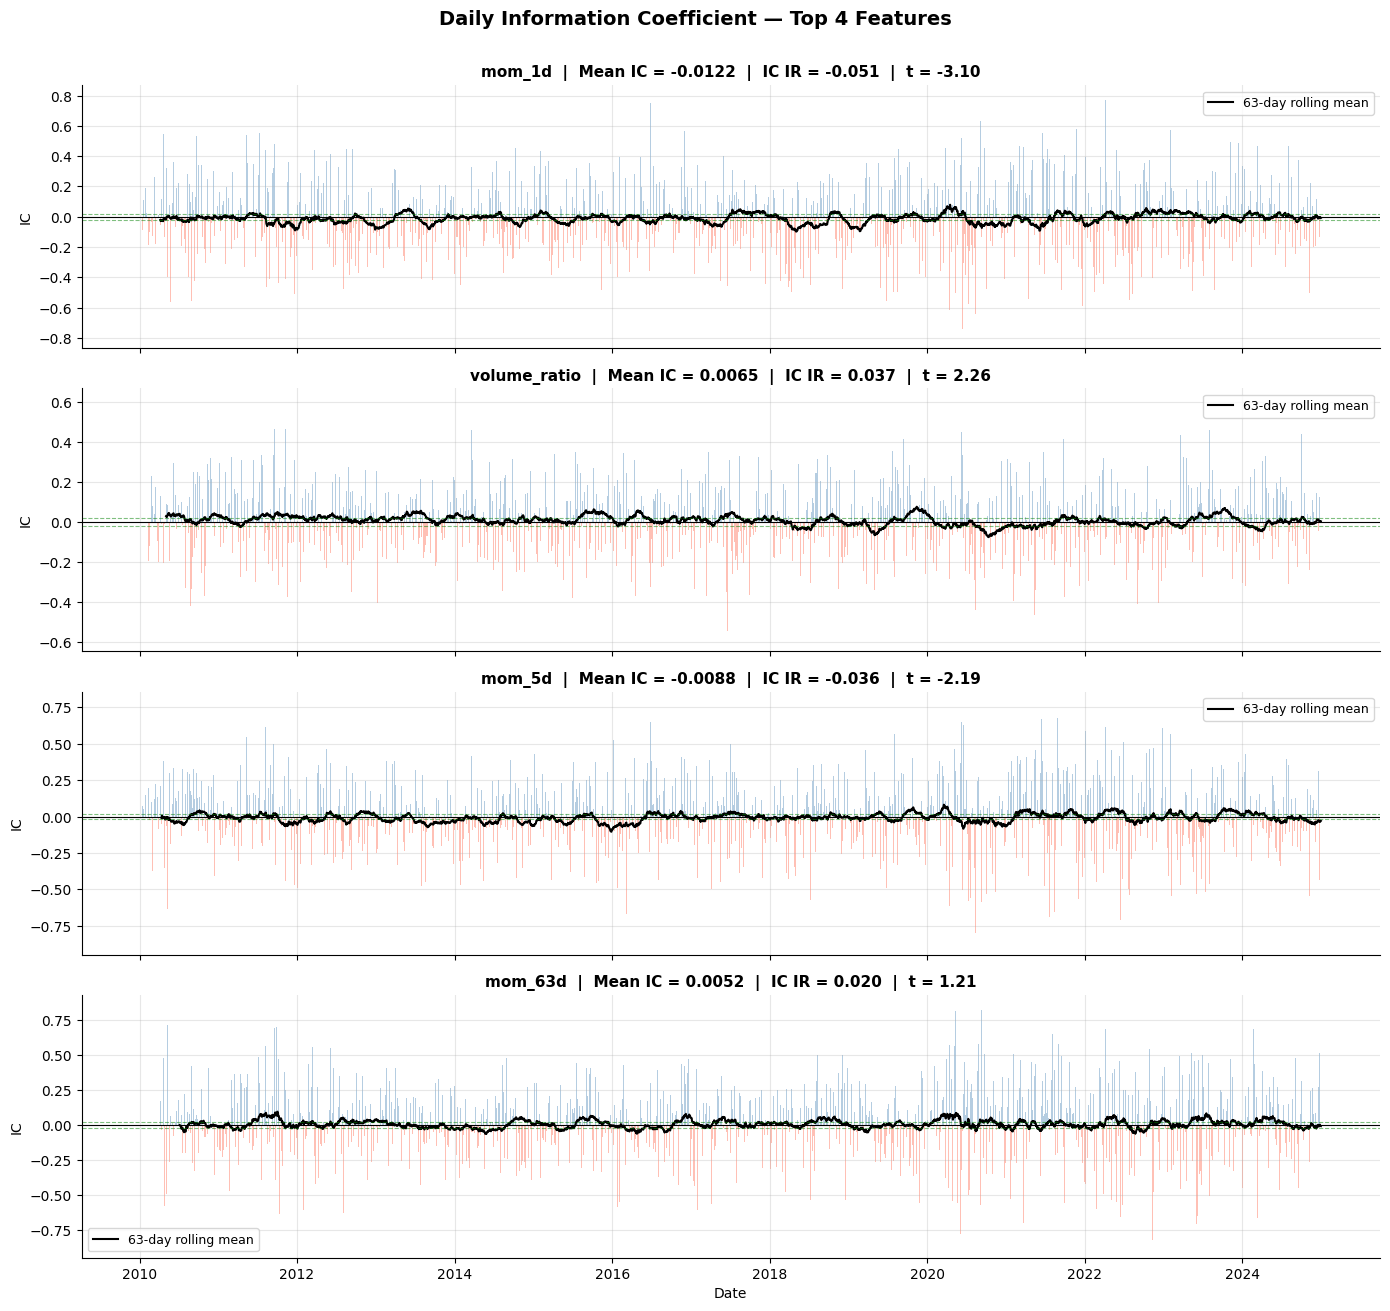

In [16]:
# IC over time — top 4 features
top4 = ic_summary.index[:4].tolist()

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)
for i, fname in enumerate(top4):
    s = ic_df[fname]
    rm = s.rolling(63).mean()
    axes[i].bar(ic_df.index, s, color=np.where(s > 0, 'steelblue', 'tomato'), alpha=0.4, width=1)
    axes[i].plot(ic_df.index, rm, 'k-', linewidth=1.5, label='63-day rolling mean')
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].axhline(0.02,  color='green', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[i].axhline(-0.02, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[i].set_title(
        f'{fname}  |  Mean IC = {ic_summary.loc[fname,"Mean IC"]:.4f}  '
        f'|  IC IR = {ic_summary.loc[fname,"IC IR"]:.3f}  '
        f'|  t = {ic_summary.loc[fname,"t-stat"]:.2f}',
        fontweight='bold', fontsize=11)
    axes[i].set_ylabel('IC')
    axes[i].legend(fontsize=9)
axes[-1].set_xlabel('Date')
plt.suptitle('Daily Information Coefficient — Top 4 Features', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

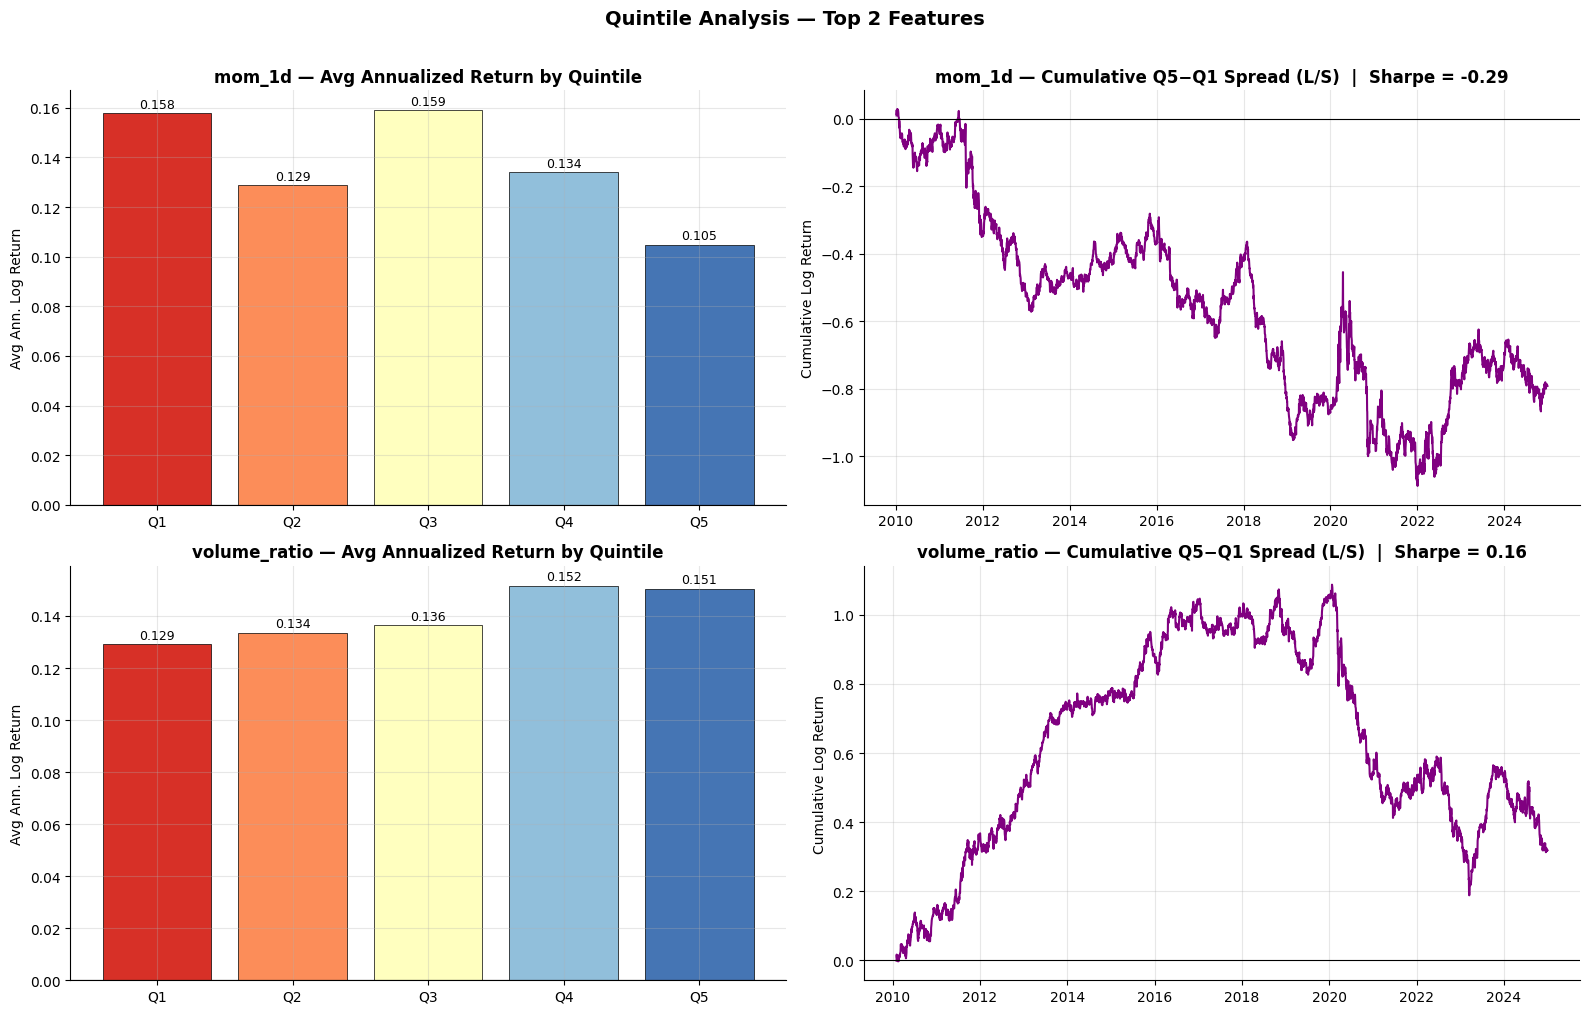

In [17]:
def quintile_analysis(df, feature, target='ret_fwd', n=5):
    d = df[['date', 'ticker', feature, target]].dropna().copy()
    d['q'] = d.groupby('date')[feature].transform(
        lambda x: pd.qcut(x, n, labels=False, duplicates='drop') + 1)
    d = d.dropna(subset=['q'])
    q_rets = d.groupby(['date', 'q'])[target].mean().unstack('q')
    q_rets.columns = [f'Q{int(c)}' for c in q_rets.columns]
    q_rets['spread'] = q_rets.get('Q5', 0) - q_rets.get('Q1', 0)
    return q_rets

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors_q = ['#d73027', '#fc8d59', '#ffffbf', '#91bfdb', '#4575b4']

for row_idx, fname in enumerate(top4[:2]):
    q = quintile_analysis(feat, fname)
    qc = [c for c in q.columns if c.startswith('Q')]
    qm = q[qc].mean() * 252

    bars = axes[row_idx][0].bar(qm.index, qm.values, color=colors_q[:len(qm)],
                                 edgecolor='black', linewidth=0.5)
    axes[row_idx][0].axhline(0, color='black', linewidth=0.8)
    axes[row_idx][0].set_title(f'{fname} — Avg Annualized Return by Quintile', fontweight='bold')
    axes[row_idx][0].set_ylabel('Avg Ann. Log Return')
    for bar, val in zip(bars, qm.values):
        axes[row_idx][0].text(bar.get_x() + bar.get_width()/2,
                               bar.get_height() + 0.001,
                               f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    spread_sharpe = q['spread'].mean() / q['spread'].std() * np.sqrt(252)
    axes[row_idx][1].plot(q.index, q['spread'].cumsum(), color='purple', linewidth=1.5)
    axes[row_idx][1].axhline(0, color='black', linewidth=0.8)
    axes[row_idx][1].set_title(
        f'{fname} — Cumulative Q5−Q1 Spread (L/S)  |  Sharpe = {spread_sharpe:.2f}',
        fontweight='bold')
    axes[row_idx][1].set_ylabel('Cumulative Log Return')

plt.suptitle('Quintile Analysis — Top 2 Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

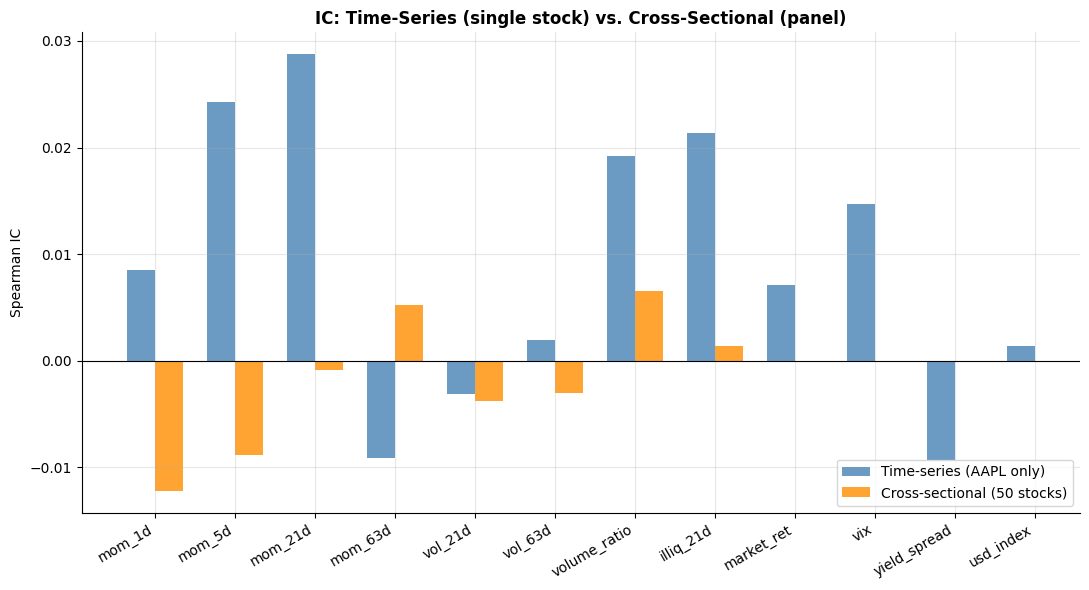

Key insight:
  Time-series IC (AAPL only): noisy, often near zero — too few observations
  Cross-sectional IC (panel): more stable — N is 50x larger per period
  → Cross-sectional is the standard approach in quantitative investing


In [18]:
# ── F3. Time-series vs. cross-sectional side-by-side ─────────────
aapl_feat = feat[feat['ticker'] == 'AAPL'].sort_values('date')
ts_rows = []
for f in FEATURE_COLS:
    valid = aapl_feat[[f, 'ret_fwd']].dropna()
    if len(valid) > 50:
        c, pv = stats.spearmanr(valid[f], valid['ret_fwd'])
        ts_rows.append({'feature': f, 'IC': c, 'p-value': pv})
ts_ic = pd.DataFrame(ts_rows).set_index('feature')

comparison = ts_ic[['IC']].rename(columns={'IC': 'TS: AAPL only'})\
    .join(ic_summary[['Mean IC']].rename(columns={'Mean IC': 'XS: all 50 stocks'}))

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison['TS: AAPL only'],     width=w, label='Time-series (AAPL only)', color='steelblue', alpha=0.8)
ax.bar(x + w/2, comparison['XS: all 50 stocks'], width=w, label='Cross-sectional (50 stocks)', color='darkorange', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=30, ha='right')
ax.set_title('IC: Time-Series (single stock) vs. Cross-Sectional (panel)', fontsize=12, fontweight='bold')
ax.set_ylabel('Spearman IC')
ax.legend()
plt.tight_layout()
plt.show()

print('Key insight:')
print('  Time-series IC (AAPL only): noisy, often near zero — too few observations')
print('  Cross-sectional IC (panel): more stable — N is 50x larger per period')
print('  → Cross-sectional is the standard approach in quantitative investing')

---
# Summary

### Dataset we will use for the entire series

| File | Contents |
|---|---|
| `ds4fe_panel.parquet` | 50 US stocks, daily OHLCV, 2010–2024, 187k rows |
| `ds4fe_market.parquet` | SPY, VIX, yield curve (10y, 3m, spread), USD index |
| `ds4fe_info.csv` | Sector, company name, market cap |

### Features built today

```
X = ['mom_1d', 'mom_5d', 'mom_21d', 'mom_63d',
     'vol_21d', 'vol_63d', 'volume_ratio', 'illiq_21d',
     'market_ret', 'vix', 'yield_spread', 'usd_index']

y = 'ret_fwd'  # next-day log return
```

### Key takeaways

1. Return direction is hard to predict; volatility is not.
2. Market beta explains ~40–60% of daily variance — macro context matters.
3. Cross-sectional prediction is more tractable than single-stock time-series.
4. Look-ahead bias is the most common mistake — always shift your features.
5. VIX and yield spread carry cross-sectional predictive signal.

---
### Coming up in Part 2
- Combine all features into Linear Regression, Random Forest, XGBoost
- Proper **walk-forward evaluation** (no shuffle, no data leakage)
- Build a **long-short portfolio** from model predictions
- Diagnose overfitting

---
### Exercises
1. Add `mom_252d` (12-month momentum). Does it have higher IC than `mom_63d`?
2. Compute **sector-neutral IC**: demean each feature within sector before IC. Do results change?
3. Does high `illiq_21d` predict higher or lower next-day returns? Why?
4. How does `market_ret` IC compare to `mom_1d`? What does this say about market-wide momentum?
5. *(Challenge)* Compute rolling 63-day IC for `vix` and overlay with VIX level. Does VIX predict better during high-volatility regimes?